In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('hotel_bookings.csv')

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
df[['agent']] = df[['agent']].fillna(0)
df[['company']] = df[['company']].fillna(0)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)

In [8]:
df[['country']]= df[['country']].fillna('Unknown')
df['country'] = df['country'].astype(str)

In [9]:
mode = df['children'].mode()[0]
df['children'] = df['children'].fillna(mode)
df['children'] = df['children'].astype(int)

In [10]:
print(df.isnull().sum().sum())

0


In [11]:
df['is_company_booking'] = (df['company'] != 0).astype(int)

df = df.drop(columns=['company'])

In [12]:
top20_countries = df['country'].value_counts().head(20).index

df.loc[~df['country'].isin(top20_countries), 'country'] = 'Other Country'


In [13]:
top20_agent = df['agent'].value_counts().head(20).index
df['agent'] = df['agent'].mask(~df['agent'].isin(top20_agent), 'Other Agent')


In [14]:
df['agent'] = df['agent'].astype(str)

In [15]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

In [16]:
df['month'] = df['arrival_date'].dt.month
df['week'] = df['arrival_date'].dt.isocalendar().week
df['dayofweek'] = df['arrival_date'].dt.dayofweek

In [17]:
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

In [18]:
df = df.drop(columns=[
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_week_number',
    'arrival_date_day_of_month'
])

In [19]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [20]:
df['is_room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

df['has_booking_changes'] = (df['booking_changes'] > 0).astype(int)

In [21]:
df['is_demanding_customer'] = (df['total_of_special_requests'] > 0).astype(int)

In [22]:
drop_cols = [
    'reservation_status',
    'reservation_status_date',
    'adults', 'children', 'babies',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'booking_changes',
    'total_of_special_requests'
]

df = df.drop(columns=drop_cols)

In [23]:
monthly_cancellation = (
    df.groupby('month')['is_canceled']
    .mean()
    .sort_index() * 100
)

print("Cancellation rate by month (%):")
print(monthly_cancellation)

Cancellation rate by month (%):
month
1     30.477315
2     33.415964
3     32.152338
4     40.797186
5     39.665847
6     41.457172
7     37.453598
8     37.753117
9     39.170156
10    38.046595
11    31.233441
12    34.970501
Name: is_canceled, dtype: float64


In [24]:
import os
os.makedirs("plots", exist_ok=True)

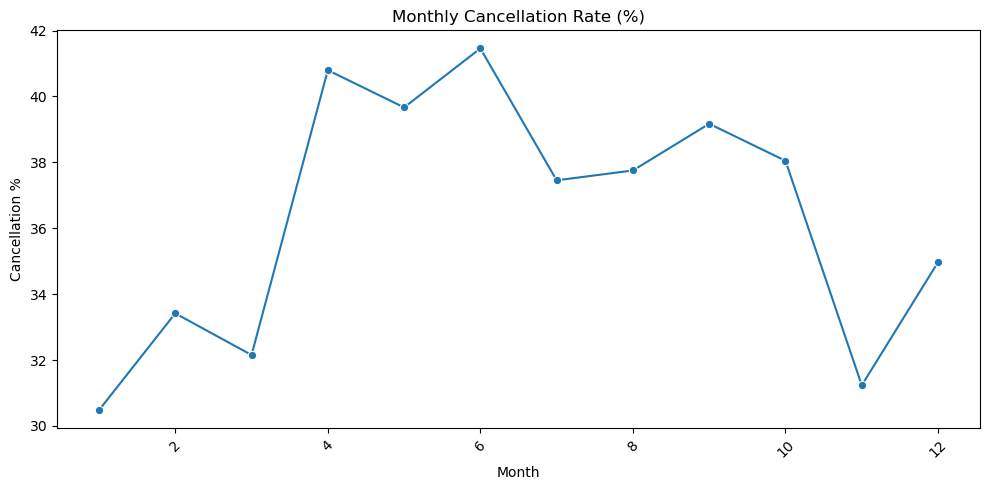

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_cancellation.index,
    y=monthly_cancellation.values,
    marker='o'
)

plt.title("Monthly Cancellation Rate (%)")
plt.xlabel("Month")
plt.ylabel("Cancellation %")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/monthly_cancellation_rate.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
cancellation_rate = df['is_canceled'].mean() * 100
print(f"Overall cancellation rate: {cancellation_rate:.2f}%")

Overall cancellation rate: 37.04%


In [27]:
hotel_cancellation = (
    df.groupby('hotel')['is_canceled']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Cancellation rate by hotel type:")
print(hotel_cancellation)

Cancellation rate by hotel type:
hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64


In [28]:
lead_time_cancellation = (
    df.groupby('is_canceled')['lead_time']
    .median()
)

print("Median lead time for canceled vs non-canceled bookings:")
print(lead_time_cancellation)

Median lead time for canceled vs non-canceled bookings:
is_canceled
0     45.0
1    113.0
Name: lead_time, dtype: float64


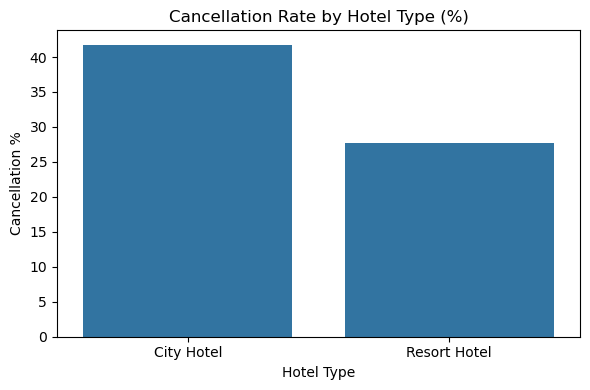

In [53]:
plt.figure(figsize=(6,4))
sns.barplot(x=hotel_cancellation.index, y=hotel_cancellation.values)

plt.title("Cancellation Rate by Hotel Type (%)")
plt.ylabel("Cancellation %")
plt.xlabel("Hotel Type")

plt.tight_layout()
plt.savefig("plots/cancellation_rate_by_hotel_type.png", dpi=300)

plt.show()

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

y = df['is_canceled']
X = df.drop(columns=['is_canceled', 'arrival_date'])

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('NUM', num_pipeline, num_cols),
    ('CAT', cat_pipeline, cat_cols),
])

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [33]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression
Accuracy: 0.8343


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest
Accuracy: 0.8979


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     14907
           1       0.89      0.83      0.86      8971

    accuracy                           0.90     23878
   macro avg       0.90      0.88      0.89     23878
weighted avg       0.90      0.90      0.90     23878



In [36]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost
Accuracy: 0.8713


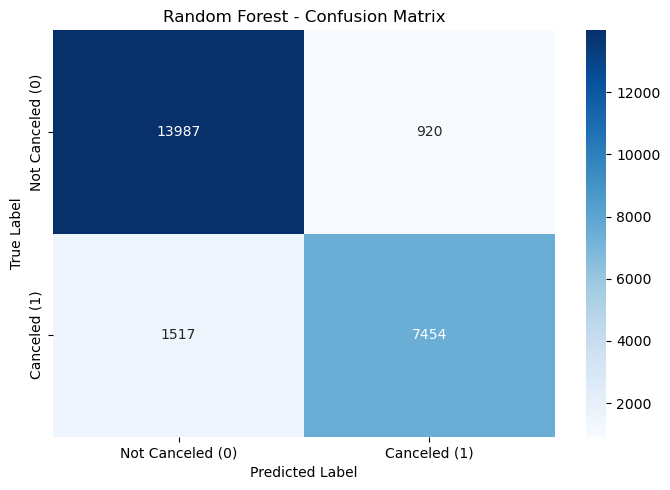

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("plots", exist_ok=True)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled (0)', 'Canceled (1)'],
    yticklabels=['Not Canceled (0)', 'Canceled (1)']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig("plots/confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_dist = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [None, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", 0.3],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

rf_search.fit(X_train, y_train)

y_pred = rf_search.predict(X_test)

print("\n=== TUNED RANDOM FOREST RESULTS ===")
print(f"Best Params: {rf_search.best_params_}")
print(f"Best CV Accuracy: {rf_search.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNED RANDOM FOREST RESULTS ===
Best Params: {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.3, 'classifier__max_depth': None}
Best CV Accuracy: 0.8906
Test Accuracy: 0.8987

Confusion Matrix:
[[13896  1011]
 [ 1409  7562]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     14907
           1       0.88      0.84      0.86      8971

    accuracy                           0.90     23878
   macro avg       0.90      0.89      0.89     23878
weighted avg       0.90      0.90      0.90     23878



In [39]:
print(rf_search.best_params_)

{'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.3, 'classifier__max_depth': None}


In [41]:
import joblib
joblib.dump(rf_search.best_estimator_, "best_model.pkl")

['best_model.pkl']

In [42]:
import json
json.dump(rf_search.best_params_, open("best_params.json","w"), indent=4)

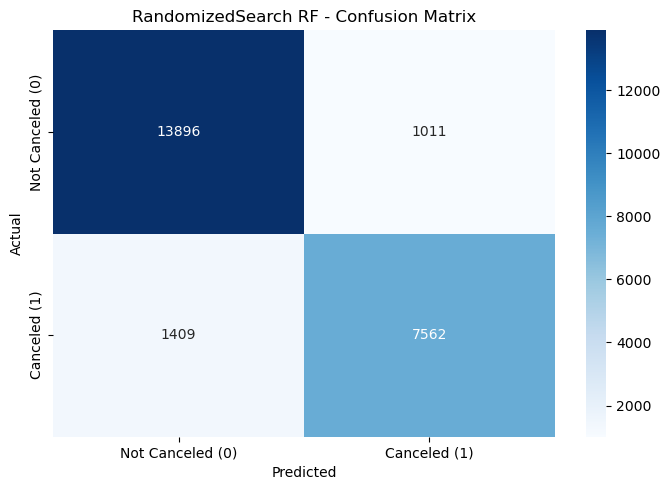

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

os.makedirs("plots", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled (0)', 'Canceled (1)'],
    yticklabels=['Not Canceled (0)', 'Canceled (1)']
)

plt.title("RandomizedSearch RF - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("plots/rf_confusion_matrix_tuned.png", dpi=300, bbox_inches="tight")

plt.show()

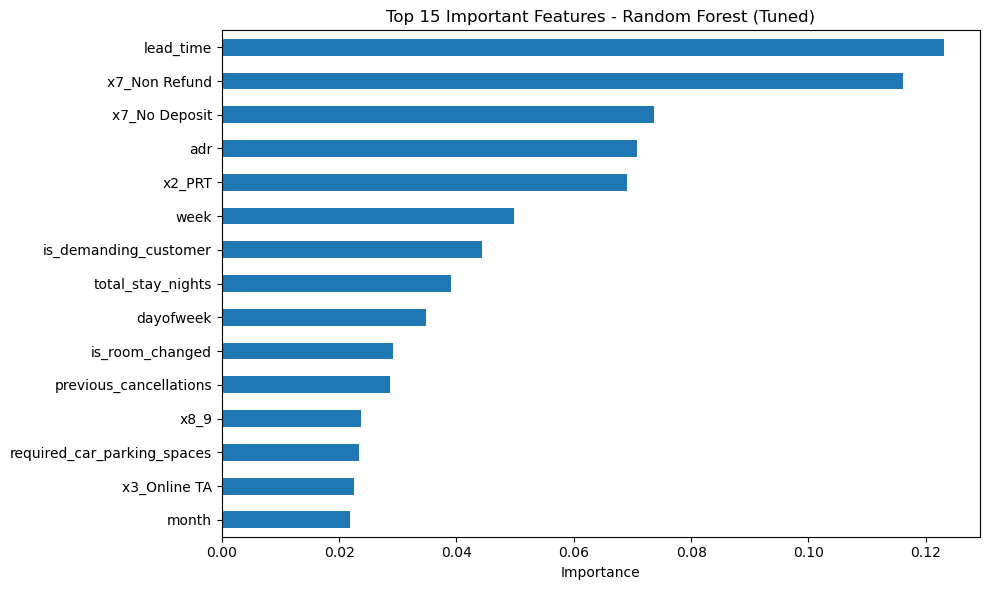

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ohe = rf_search.best_estimator_.named_steps['preprocessor'] \
    .named_transformers_['CAT'] \
    .named_steps['ohe']

cat_features = ohe.get_feature_names_out()

num_features = num_cols  # əgər sən əvvəl define etmisənsə

all_features = np.concatenate([num_features, cat_features])

importances = rf_search.best_estimator_.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=all_features)
top_features = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

top_features.sort_values().plot(kind='barh')

plt.title("Top 15 Important Features - Random Forest (Tuned)")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("plots/feature_importance_rf.png", dpi=300, bbox_inches="tight")

plt.show()